# Data Preparation for EDA and clustering steps

In [1]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.class_pipeline_functions as cpf
import src.code.io_utils as io

importlib.reload(cpf)
importlib.reload(io)

import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.code.class_pipeline_functions import ClientFeatureEngineer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

# Path 
ABT_OUT_PATH  = "../data/prepared/abt.parquet"

In [2]:
customer = io.load(ABT_OUT_PATH)
customer.head(5)

[LOAD] ../data/prepared/abt.parquet | shape: (148729, 91)


,CONTRIB,N_CONTRACTS,HAS_ACTIVE,FIRST_DCREAT,LAST_DCREAT,LAST_DPOS,LAST_DATFIN,FIRST_D1FIN,MIN_DURDEG,MAX_DURDEG,MEDIAN_DURDEG,MIN_RANGPRO,MAX_RANGPRO,MEDIAN_RANGPRO,MIN_RANGCLI,MAX_RANGCLI,MEDIAN_RANGCLI,TOTAL_MTFIN,TOTAL_MTFINO,TOTAL_MENSALIDADE,TOTAL_CRD,TOTAL_SREC,TOTAL_RN,TOTAL_RD,LAST_RISK,MAX_RISKA,MIN_RESSO,MAX_RESSO,MEDIAN_RESSO,CSP,...,MONTVENC_CP_MEDIAN,MONTVENC_AUTO_MIN,MONTVENC_AUTO_MAX,MONTVENC_AUTO_MEDIAN,MONTVENC_HT_MIN,MONTVENC_HT_MAX,MONTVENC_HT_MEDIAN,DIVIDAS_CL_MIN,DIVIDAS_CL_MAX,DIVIDAS_CL_MEDIAN,DIVIDAS_CP_MIN,DIVIDAS_CP_MAX,DIVIDAS_CP_MEDIAN,DIVIDAS_AUTO_MIN,DIVIDAS_AUTO_MAX,DIVIDAS_AUTO_MEDIAN,DIVIDAS_HT_MIN,DIVIDAS_HT_MAX,DIVIDAS_HT_MEDIAN,sys_data_procura,kp_sqe_enc,ks_score_tier,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2,0,2024-06-25,2024-09-13,2025-11-17,2024-09-30,2024-06-27,84.000,120.000,102.000,3.000,13.000,8.000,19.000,19.000,19.000,24000.000,24000.000,438.761,0.000,0.000,0.000,0.000,000000000000000000000000,0.000,1513.466,1513.466,1513.466,80.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,8000.000,0.000,1.650,3701.730,978.250,0.000,58633.860,15934.050,0.000,0.000,0.000,2025-02-05,7.000,2.000,10.000,1.000,2.000,-438.900,10.000,S,F,33.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,1,1,2018-03-29,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.000,120.000,120.000,91.000,91.000,91.000,91.000,91.000,91.000,20000.000,20000.000,347.447,8115.247,0.000,0.000,0.000,000000000000000000000000,0.000,1113.258,1113.258,1113.258,80.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,20308.940,69754.560,24983.220,5499.880,21274.830,7115.460,0.000,0.000,0.000,0.000,0.000,0.000,2025-04-09,3.000,1.000,10.000,1.000,0.000,1166.900,10.000,C,P,52.000
2,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,2,0,2001-09-21,2001-09-27,2014-06-27,2001-10-04,2001-09-21,60.000,60.000,60.000,21.000,21.000,21.000,21.000,21.000,21.000,19453.110,19453.110,608.914,0.000,0.000,2.000,24.000,444444444444444444444444,0.000,678.483,678.483,678.483,60.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN
3,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,1,0,2019-01-28,2019-01-28,2022-12-28,2019-02-04,2019-02-04,72.000,72.000,72.000,34.000,34.000,34.000,34.000,34.000,34.000,2500.000,2500.000,56.018,0.000,0.000,1.000,1.000,000000000000210210000110,0.000,838.186,838.186,838.186,91.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,3.000,0.000,0.000,590.333,3.000,S,A,69.000
4,0000f858346061c53064586a3347b34659565a6712d004...,1,1,2019-09-23,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.000,84.000,84.000,74.000,74.000,74.000,74.000,74.000,74.000,5000.000,5000.000,100.074,883.500,0.000,0.000,0.000,000000000000000000000000,0.000,1314.144,1314.144,1314.144,80.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1019.130,2957.280,2114.780,1465.730,3475.320,1743.460,773.460,2408.560,1695.620,83852.710,168563.040,84906.010,NaT,NaN,NaN,4.000,1.000,1.000,1358.250,4.000,U,A,39.000


In [3]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148729 entries, 0 to 148728
Data columns (total 91 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   CONTRIB               148729 non-null  object        
 1   N_CONTRACTS           148729 non-null  int64         
 2   HAS_ACTIVE            148729 non-null  int64         
 3   FIRST_DCREAT          148729 non-null  datetime64[ns]
 4   LAST_DCREAT           148729 non-null  datetime64[ns]
 5   LAST_DPOS             148729 non-null  datetime64[ns]
 6   LAST_DATFIN           148729 non-null  datetime64[ns]
 7   FIRST_D1FIN           148729 non-null  datetime64[ns]
 8   MIN_DURDEG            148729 non-null  float64       
 9   MAX_DURDEG            148729 non-null  float64       
 10  MEDIAN_DURDEG         148729 non-null  float64       
 11  MIN_RANGPRO           148729 non-null  float64       
 12  MAX_RANGPRO           148729 non-null  float64       
 13 

In [4]:
customer.describe()

,N_CONTRACTS,HAS_ACTIVE,FIRST_DCREAT,LAST_DCREAT,LAST_DPOS,LAST_DATFIN,FIRST_D1FIN,MIN_DURDEG,MAX_DURDEG,MEDIAN_DURDEG,MIN_RANGPRO,MAX_RANGPRO,MEDIAN_RANGPRO,MIN_RANGCLI,MAX_RANGCLI,MEDIAN_RANGCLI,TOTAL_MTFIN,TOTAL_MTFINO,TOTAL_MENSALIDADE,TOTAL_CRD,TOTAL_SREC,TOTAL_RN,TOTAL_RD,MAX_RISKA,MIN_RESSO,MAX_RESSO,MEDIAN_RESSO,CSP,NBENF,EVER_SOL,...,MONTVENC_CP_MIN,MONTVENC_CP_MAX,MONTVENC_CP_MEDIAN,MONTVENC_AUTO_MIN,MONTVENC_AUTO_MAX,MONTVENC_AUTO_MEDIAN,MONTVENC_HT_MIN,MONTVENC_HT_MAX,MONTVENC_HT_MEDIAN,DIVIDAS_CL_MIN,DIVIDAS_CL_MAX,DIVIDAS_CL_MEDIAN,DIVIDAS_CP_MIN,DIVIDAS_CP_MAX,DIVIDAS_CP_MEDIAN,DIVIDAS_AUTO_MIN,DIVIDAS_AUTO_MAX,DIVIDAS_AUTO_MEDIAN,DIVIDAS_HT_MIN,DIVIDAS_HT_MAX,DIVIDAS_HT_MEDIAN,sys_data_procura,kp_sqe_enc,ks_score_tier,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_age
count,148729.000,148729.000,148729,148729,148729,148729,148729,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,148729.000,...,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,141663.000,62173,62173.000,62173.000,141115.000,141115.000,141115.000,141115.000,141115.000,141115.000
mean,1.248,0.665,2021-11-26 00:55:05.448163584,2022-05-13 12:16:22.630152704,2024-01-03 17:54:06.363520256,2022-05-22 06:24:52.825205504,2021-12-04 06:36:57.235374080,69.853,74.417,72.129,30.974,35.070,32.889,43.978,44.207,44.110,11521.808,11521.624,262.458,5917.065,-6.465,0.340,1.134,0.083,1443.922,1493.280,1469.255,62.417,0.612,0.183,...,4.725,207.192,30.687,4.977,83.138,13.782,4.985,147.024,28.034,6795.433,22142.234,10722.432,1248.404,5200.607,2400.276,3112.368,10089.306,5114.468,24906.039,57096.301,29331.216,2024-08-28 02:52:59.450886912,2.152,1.582,8.570,0.782,0.683,438.160,8.570,45.050
min,1.000,0.000,1996-06-14 00:00:00,1996-06-26 00:00:00,2014-06-27 00:00:00,1996-07-03 00:00:00,1996-06-14 00:00:00,11.000,11.000,11.000,0.000,0.000,0.000,0.000,0.000,0.000,300.000,300.000,0.621,0.000,-2641.014,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2020-08-12 00:00:00,0.000,1.000,1.000,0.000,0.000,-2382.500,1.000,18.000
25%,1.000,0.000,2020-06-29 00:00:00,2020-12-22 00:00:00,2023-08-31 00:00:00,2020-12-30 00:00:00,2020-07-07 00:00:00,48.000,48.000,48.000,9.000,14.000,12.000,22.000,22.000,22.000,4900.000,4900.000,115.076,0.000,0.000,0.000,0.000,0.000,948.935,977.381,963.831,55.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3500.000,1157.435,0.000,724.565,129.830,0.000,0.000,0.000,0.000,0.000,0.000,2023-12-16 00:00:00,0.000,1.000,4.000,0.000,0.000,-716.750,4.000,36.000
50%,1.000,1.000,2022-08-17 00:00:00,2023-04-03 00:00:00,2024-10-02 00:00:00,2023-04-11 00:00:00,2022-08-26 00:00:00,81.000,84.000,84.000,24.000,30.000,27.000,39.000,39.000,39.000,7634.360,7633.110,187.685,2800.762,0.000,0.000,0.000,0.000,1214.224,1247.041,1230.628,70.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2445.450,10934.160,5946.660,195.250,2296.270,1076.080,0.000,1175.990,0.000,0.000,0.000,0.000,2024-10-11 00:00:00,1.000,1.000,7.000,1.000,1.000,253.786,7.000,44.000
75%,1.000,1.000,2024-04-06 00:00:00,2024-11-15 00:00:00,2025-07-01 00:00:00,2024-11-22 00:00:00,2024-04-11 00:00:00,84.000,84.000,84.000,48.000,52.000,48.000,61.000,61.000,61.000,15000.000,15000.000,323.692,8179.504,0.000,0.000,0.000,0.000,1713.806,1747.056,1731.813,80.000,1.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,9121.730,25932.710,14665.720,1300.885,6118.600,3010.030,3265.190,14000.000,8039.345,36078.110,72281.960,46964.73

## 1. Missing values analysis

In [5]:
# Check for columns with >= 30% missing values
null_pct = (customer.isnull().sum() / len(customer) * 100).round(2)
high_missing = null_pct[null_pct >= 30].sort_values(ascending=False)

print(f"Columns with >= 30% missing values: {len(high_missing)}\n")
if len(high_missing) > 0:
    display(high_missing.to_frame("null_%"))
else:
    print("None found. All columns have < 30% missing.")

Columns with >= 30% missing values: 7



,null_%
LAST_OBS_DATE_RBT,97.900
LAST_OBS_DATE_SOL,81.670
LAST_OBS_DATE_SAN,72.700
sys_data_procura,58.200
kp_sqe_enc,58.200
ks_score_tier,58.200
TIME_TO_CHURN_D,54.660


In [6]:
# Drop columns with >= 30% missing values
cols_to_drop = ['LAST_OBS_DATE_RBT', 'LAST_OBS_DATE_SOL', 'LAST_OBS_DATE_SAN',
                'sys_data_procura', 'kp_sqe_enc', 'ks_score_tier']

customer.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"New shape: {customer.shape}")

Dropped 6 columns: ['LAST_OBS_DATE_RBT', 'LAST_OBS_DATE_SOL', 'LAST_OBS_DATE_SAN', 'sys_data_procura', 'kp_sqe_enc', 'ks_score_tier']
New shape: (148729, 85)


In [7]:
# Drop rows with > 50% missing values
threshold = 0.5
min_non_null = int(threshold * customer.shape[1])  # minimum non-null values required
rows_before = customer.shape[0]
customer.dropna(thresh=min_non_null, inplace=True)
rows_after = customer.shape[0]
print(f"Dropped {rows_before - rows_after} rows with > 50% missing values")
print(f"New shape: {customer.shape}")

Dropped 1314 rows with > 50% missing values
New shape: (147415, 85)


## 2. Converting datetime features to numeric

In [8]:
date_cols = customer.select_dtypes(include=['datetime64', 'datetimetz']).columns.tolist()
print(f"Date columns ({len(date_cols)}):\n")
for col in date_cols:
    print(f"  - {col}")

Date columns (5):

  - FIRST_DCREAT
  - LAST_DCREAT
  - LAST_DPOS
  - LAST_DATFIN
  - FIRST_D1FIN


In [9]:
ref_date = pd.Timestamp('2025-11-30')

# Total client seniority (years)
customer['CLIENT_SENIORITY_YEARS'] = (ref_date - customer['FIRST_DCREAT']).dt.days / 365.25

# Months since creation of last contract (recency)
customer['YEARS_SINCE_LAST_CONTRACT'] = (ref_date - customer['LAST_DCREAT']).dt.days / 365.25

# Months remaining until end of current contract (can be negative, represents how many time has passed since )
#customer['MONTHS_TO_CONTRACT_END'] = (customer['LAST_DATFIN'] - ref_date).dt.days / 30

# Current contract duration (months)
#customer['CURRENT_CONTRACT_DURATION_MONTHS'] = (customer['LAST_DATFIN'] - customer['LAST_DCREAT']).dt.days / 30

# First contract duration (historical profile)
#customer['FIRST_CONTRACT_DURATION_MONTHS'] = (customer['FIRST_D1FIN'] - customer['FIRST_DCREAT']).dt.days / 30

# Years between first and last contract (repeat behaviour)
#customer['YEARS_BETWEEN_FIRST_AND_LAST'] = (customer['LAST_DCREAT'] - customer['FIRST_DCREAT']).dt.days / 365.25

In [10]:
customer = customer.drop(columns=date_cols)
print(f"Shape: {customer.shape}")

Shape: (147415, 82)


## 3. Feature Engineering

In [11]:
customer['DIVIDAS_TOTAL_MEDIAN'] = customer[['DIVIDAS_CL_MEDIAN', 'DIVIDAS_CP_MEDIAN', 'DIVIDAS_AUTO_MEDIAN', 'DIVIDAS_HT_MEDIAN']].sum(axis=1)

In [12]:
customer['MONTVENC_TOTAL_MAX'] = customer[['MONTVENC_CL_MAX', 'MONTVENC_CP_MAX', 'MONTVENC_AUTO_MAX', 'MONTVENC_HT_MAX']].sum(axis=1)

In [13]:
customer['MONTVENC_TOTAL_LOG'] = np.log1p(customer['MONTVENC_TOTAL_MAX'].clip(lower=0))

In [14]:
# Debt-to-income ratio — classic financial stress indicator
#customer['DEBT_TO_INCOME'] = customer['DIVIDAS_TOTAL_MEDIAN'] / (customer['MEDIAN_RESSO'] + 1e-6)

In [15]:
# Monthly commitment ratio — share of income allocated to loan instalments
#customer['MENSALIDADE_TO_RESSO'] = customer['TOTAL_MENSALIDADE'] / (customer['MEDIAN_RESSO'] + 1e-6)

In [16]:
# External credit exposure relative to Cetelem
# High value = client has many external credits → potential competitor exposure
customer['EXTERNAL_TO_CETELEM'] = customer['COUNT_TOTAL_MEDIAN'] / (customer['N_CONTRACTS'] + 1e-6)

In [17]:
# ── RISK_EVER — flag: at least one non-zero digit in the 24-char risk string ──
risk_str = customer['LAST_RISK'].astype(str).str.strip()
customer['RISK_EVER'] = risk_str.str.contains(r'[1-9]', regex=True, na=False).astype(int)

In [18]:
# ── RISK_RECENT — flag: any non-zero digit in the last 6 characters (last 6 months) ──
customer['RISK_RECENT'] = risk_str.str[-6:].str.contains(r'[1-9]', regex=True, na=False).astype(int)

In [19]:
#customer['MEDIAN_RESSO_LOG'] = np.log1p(customer['MEDIAN_RESSO'])

In [20]:
#customer['FLAG_RN'] = (customer['TOTAL_RN'] > 0).astype(int)
#customer['FLAG_RD'] = (customer['TOTAL_RD'] > 0).astype(int)

## 4. Outliers removal

In [21]:
# Check current state of negative values
n_neg = (customer['ALLBD_IDADE_MEAN__N'] < 0).sum()
pct_neg = (customer['ALLBD_IDADE_MEAN__N'] < 0).mean() * 100
print(f"Negative values before transform: {n_neg:,} ({pct_neg:.1f}%)")
print(f"\nDistribution before:")
print(customer['ALLBD_IDADE_MEAN__N'].describe().round(3))

# Transform negative values to positive using abs()
customer['ALLBD_IDADE_MEAN__N'] = customer['ALLBD_IDADE_MEAN__N'].abs()

# Verify
print(f"\nNegative values after transform: {(customer['ALLBD_IDADE_MEAN__N'] < 0).sum()}")
print(f"\nDistribution after:")
print(customer['ALLBD_IDADE_MEAN__N'].describe().round(3))

Negative values before transform: 61,317 (41.6%)

Distribution before:
count   141115.000
mean       438.160
std       1545.012
min      -2382.500
25%       -716.750
50%        253.786
75%       1411.279
max       7435.500
Name: ALLBD_IDADE_MEAN__N, dtype: float64

Negative values after transform: 0

Distribution after:
count   141115.000
mean      1247.179
std       1011.721
min          0.000
25%        490.000
50%       1028.250
75%       1744.000
max       7435.500
Name: ALLBD_IDADE_MEAN__N, dtype: float64


In [22]:
customer = customer[customer['MAX_RISKA'] != 7].copy()
print(f"Remaining clients: {len(customer):,} ")

Remaining clients: 146,628 


In [23]:
cat_cols = customer.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = customer.select_dtypes(include=['number']).columns.tolist()

In [24]:
# For variables with IQR < threshold — cap before scaling
for col in num_cols:
    q1 = customer[col].quantile(0.25)
    q3 = customer[col].quantile(0.75)
    iqr = q3 - q1
    
    if iqr < 1.0:  # low IQR threshold
        p01 = customer[col].quantile(0.01)
        p99 = customer[col].quantile(0.99)
        customer[col] = customer[col].clip(lower=p01, upper=p99)
        print(f"  {col}: IQR={iqr:.3f} → capped at [{p01:.3f}, {p99:.3f}]")

  N_CONTRACTS: IQR=0.000 → capped at [1.000, 4.000]
  TOTAL_SREC: IQR=0.000 → capped at [-370.144, 13.462]
  TOTAL_RN: IQR=0.000 → capped at [0.000, 4.000]
  TOTAL_RD: IQR=0.000 → capped at [0.000, 12.000]
  MAX_RISKA: IQR=0.000 → capped at [0.000, 1.000]
  EVER_SOL: IQR=0.000 → capped at [0.000, 1.000]
  N_SOL: IQR=0.000 → capped at [0.000, 1.000]
  EVER_RBT: IQR=0.000 → capped at [0.000, 1.000]
  N_RBT: IQR=0.000 → capped at [0.000, 1.000]
  MONTVENC_CL_MIN: IQR=0.000 → capped at [0.000, 0.000]
  MONTVENC_CL_MAX: IQR=0.000 → capped at [0.000, 10693.725]
  MONTVENC_CL_MEDIAN: IQR=0.000 → capped at [0.000, 696.686]
  MONTVENC_CP_MIN: IQR=0.000 → capped at [0.000, 0.000]
  MONTVENC_CP_MAX: IQR=0.000 → capped at [0.000, 4847.095]
  MONTVENC_CP_MEDIAN: IQR=0.000 → capped at [0.000, 668.640]
  MONTVENC_AUTO_MIN: IQR=0.000 → capped at [0.000, 0.000]
  MONTVENC_AUTO_MAX: IQR=0.000 → capped at [0.000, 676.720]
  MONTVENC_AUTO_MEDIAN: IQR=0.000 → capped at [0.000, 0.000]
  MONTVENC_HT_MIN: IQR

In [25]:
votes_matrix = np.zeros((len(customer), len(num_cols)), dtype=int)

for i, col in enumerate(num_cols):
    s = customer[col]
    
    # IQR Method
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    iqr_mask = (s < (q1 - 3 * iqr)) | (s > (q3 + 3 * iqr))
    
    # Mod-Z Method
    med = s.median()
    mad = np.median(np.abs(s - med))
    if mad > 0:
        z_mask = (np.abs(s - med) / (mad / 0.6745)) > 3.5
        # If both methods agree for this column, mark it
        votes_matrix[:, i] = (iqr_mask & z_mask).astype(int)

# If a row has AT LEAST ONE column that is a confirmed outlier by both methods
outlier_row_mask = votes_matrix.sum(axis=1) > 0

# Save outliers for separate analysis
customer_outliers = customer[outlier_row_mask].copy()

# Keep only clean data in the main dataframe
customer = customer[~outlier_row_mask].copy()

print(f"Purification Complete:")
print(f"  - {len(customer_outliers)} rows removed and saved in 'customer_outliers'")
print(f"  - {len(customer)} clean rows remaining for K-Means.")

Purification Complete:
  - 12406 rows removed and saved in 'customer_outliers'
  - 134222 clean rows remaining for K-Means.


In [26]:
io.save(customer_outliers, "../data/prepared/customer_outliers.parquet")

[SAVE] ../data/prepared/customer_outliers.parquet | shape: (12406, 88)


## 5. Feature Scalling

In [27]:
cat_cols = customer.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = customer.select_dtypes(include=['number']).columns.tolist()

In [28]:
if 'CSP' in num_cols:
    num_cols.remove('CSP')
if 'CSP' not in cat_cols:
    cat_cols.append('CSP')

In [29]:
# Scale numerical features (RobustScaler preserves NaNs)
scaler = RobustScaler()
customer[num_cols] = scaler.fit_transform(customer[num_cols])
print(f"Scaled {len(num_cols)} numerical columns")
print(f"Shape: {customer.shape}")
customer.head()

Scaled 82 numerical columns
Shape: (134222, 88)


,CONTRIB,N_CONTRACTS,HAS_ACTIVE,MIN_DURDEG,MAX_DURDEG,MEDIAN_DURDEG,MIN_RANGPRO,MAX_RANGPRO,MEDIAN_RANGPRO,MIN_RANGCLI,MAX_RANGCLI,MEDIAN_RANGCLI,TOTAL_MTFIN,TOTAL_MTFINO,TOTAL_MENSALIDADE,TOTAL_CRD,TOTAL_SREC,TOTAL_RN,TOTAL_RD,LAST_RISK,MAX_RISKA,MIN_RESSO,MAX_RESSO,MEDIAN_RESSO,CSP,NBENF,PRODALP,EVER_SOL,N_SOL,EVER_SAN,...,MONTVENC_HT_MAX,MONTVENC_HT_MEDIAN,DIVIDAS_CL_MIN,DIVIDAS_CL_MAX,DIVIDAS_CL_MEDIAN,DIVIDAS_CP_MIN,DIVIDAS_CP_MAX,DIVIDAS_CP_MEDIAN,DIVIDAS_AUTO_MIN,DIVIDAS_AUTO_MAX,DIVIDAS_AUTO_MEDIAN,DIVIDAS_HT_MIN,DIVIDAS_HT_MAX,DIVIDAS_HT_MEDIAN,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,CLIENT_SENIORITY_YEARS,YEARS_SINCE_LAST_CONTRACT,DIVIDAS_TOTAL_MEDIAN,MONTVENC_TOTAL_MAX,MONTVENC_TOTAL_LOG,EXTERNAL_TO_CETELEM,RISK_EVER,RISK_RECENT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,1.000,-1.000,0.111,1.000,0.500,-0.538,-0.450,-0.541,-0.513,-0.538,-0.513,1.737,1.737,1.373,-0.365,0.000,0.000,0.000,000000000000000000000000,0.000,0.465,0.415,0.439,80.000,0.000,EP,0.000,0.000,1.000,...,0.000,0.000,-0.268,-0.103,-0.440,-0.143,0.303,-0.014,0.000,4.233,2.021,0.000,0.000,0.000,0.429,0.000,1.000,-0.469,0.429,S,F,-0.611,-0.495,-0.390,-0.095,0.000,0.000,-0.500,0.000,0.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,0.000,0.000,1.111,1.000,1.000,1.718,1.500,1.703,1.333,1.308,1.333,1.316,1.316,0.889,0.706,0.000,0.000,0.000,000000000000000000000000,0.000,-0.120,-0.156,-0.137,80.000,1.000,EP,0.000,0.000,0.000,...,0.000,0.000,2.167,2.950,1.566,4.280,3.783,2.229,0.000,-0.091,0.000,0.000,0.000,0.000,0.429,0.000,-1.000,0.131,0.429,C,P,0.444,1.236,1.355,0.192,0.000,0.000,1.250,0.000,0.000
3,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,0.000,-1.000,-0.222,-0.333,-0.333,0.256,0.075,0.162,-0.128,-0.154,-0.128,-0.526,-0.526,-0.656,-0.365,0.000,1.000,1.000,000000000000210210000110,0.000,-0.521,-0.548,-0.534,91.000,0.000,EP,0.000,0.000,1.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.571,-1.000,-1.000,-0.345,-0.571,S,A,1.389,1.005,1.129,-0.415,0.000,0.000,NaN,1.000,1.000
4,0000f858346061c53064586a3347b34659565a6712d004...,0.000,0.000,0.111,0.000,0.000,1.282,1.075,1.243,0.897,0.872,0.897,-0.263,-0.263,-0.423,-0.248,0.000,0.000,0.000,000000000000000000000000,0.000,0.174,0.131,0.152,80.000,2.000,EP,0.000,0.000,0.000,...,0.000,0.000,-0.146,-0.352,-0.271,1.035,0.258,0.266,0.234,0.087,0.215,2.497,2.476,1.923,-0.429,0.000,0.000,0.289,-0.429,U,A,-0.278,0.824,0.953,1.295,0.000,0.000,0.750,0.000,0.000
5,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,0.000,0.000,-0.556,-0.667,-0.667,0.282,0.100,0.189,-0.051,-0.077,-0.051,-0.158,-0.158,-0.094,0.086,0.000,0.000,0.000,000000000000000000000000,0.000,-0.239,-0.272,-0.255,80.000,0.000,EPF,0.000,0.000,0.000,...,0.000,0.000,1.958,0.843,1.408,-0.145,-0.358,-0.351,0.000,-0.091,0.000,0.000,0.000,0.000,1.429,0.000,0.000,-0.395,1.429,C,P,0.611,-0.090,0.064,0.021,0.000,0.000,0.000,0.000,0.000


## 6. Imputation of missing values

In [30]:
# 1. Impute categoricals with 'Unknown'
customer[cat_cols] = customer[cat_cols].fillna('Unknown')
# 2. Impute numericals with IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=42)
customer[num_cols] = imputer.fit_transform(customer[num_cols])
print(f"Remaining nulls: {customer.isnull().sum().sum()}")
print(f"Shape: {customer.shape}")


Remaining nulls: 0
Shape: (134222, 88)


In [31]:
customer.describe()

,N_CONTRACTS,HAS_ACTIVE,MIN_DURDEG,MAX_DURDEG,MEDIAN_DURDEG,MIN_RANGPRO,MAX_RANGPRO,MEDIAN_RANGPRO,MIN_RANGCLI,MAX_RANGCLI,MEDIAN_RANGCLI,TOTAL_MTFIN,TOTAL_MTFINO,TOTAL_MENSALIDADE,TOTAL_CRD,TOTAL_SREC,TOTAL_RN,TOTAL_RD,MAX_RISKA,MIN_RESSO,MAX_RESSO,MEDIAN_RESSO,CSP,NBENF,EVER_SOL,N_SOL,EVER_SAN,N_SAN,EVER_RBT,N_RBT,...,MONTVENC_AUTO_MEDIAN,MONTVENC_HT_MIN,MONTVENC_HT_MAX,MONTVENC_HT_MEDIAN,DIVIDAS_CL_MIN,DIVIDAS_CL_MAX,DIVIDAS_CL_MEDIAN,DIVIDAS_CP_MIN,DIVIDAS_CP_MAX,DIVIDAS_CP_MEDIAN,DIVIDAS_AUTO_MIN,DIVIDAS_AUTO_MAX,DIVIDAS_AUTO_MEDIAN,DIVIDAS_HT_MIN,DIVIDAS_HT_MAX,DIVIDAS_HT_MEDIAN,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_age,CLIENT_SENIORITY_YEARS,YEARS_SINCE_LAST_CONTRACT,DIVIDAS_TOTAL_MEDIAN,MONTVENC_TOTAL_MAX,MONTVENC_TOTAL_LOG,EXTERNAL_TO_CETELEM,RISK_EVER,RISK_RECENT
count,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,...,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000,134222.000
mean,0.218,-0.325,-0.293,-0.288,-0.346,0.194,0.108,0.145,0.120,0.099,0.123,0.267,0.267,0.268,0.306,-8.827,0.316,0.968,0.047,0.182,0.193,0.188,62.921,0.606,0.166,0.166,0.271,0.316,0.021,0.021,...,0.000,0.000,8.484,0.000,0.370,0.358,0.230,0.837,0.534,0.462,0.923,0.616,0.627,0.676,0.742,0.596,0.200,-0.212,-0.311,0.150,0.200,0.022,0.103,0.138,0.377,474.454,1.306,0.077,0.155,0.114
std,0.525,0.469,0.832,0.819,0.807,0.667,0.642,0.683,0.699,0.698,0.698,0.855,0.855,0.865,0.851,48.133,0.780,2.630,0.212,1.025,1.001,1.005,20.456,0.865,0.372,0.372,0.444,0.573,0.143,0.143,...,0.000,0.000,60.820,0.000,1.299,1.695,1.186,1.914,1.535,1.210,1.851,1.213,1.030,1.204,1.432,0.997,0.850,0.599,0.781,0.730,0.850,0.654,0.679,0.670,0.898,2266.341,2.634,0.741,0.362,0.318
min,0.000,-1.000,-1.889,-2.000,-2.000,-0.615,-0.775,-0.757,-1.000,-1.026,-1.000,-0.758,-0.758,-0.950,-0.365,-370.144,0.000,0.000,0.000,-1.746,-1.742,-1.740,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,-37.732,0.000,-3.774,-4.502,-4.083,-0.145,-0.430,-0.371,0.000,-0.091,0.000,0.000,-1.155,0.000,-0.857,-1.144,-2.089,-1.101,-0.857,-1.792,-0.894,-0.718,-0.415,0.000,0.000,-1.250,0.000,0.000
25%,0.000,-1.000,-0.889,-1.000,-1.000,-0.385,-0.450,-0.432,-0.436,-0.462,-0.436,-0.316,-0.316,-0.358,-0.365,0.000,0.000,0.000,0.000,-0.360,-0.355,-0.357,56.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,-0.268,-0.358,-0.377,-0.145,-0.288,-0.324,0.000,-0.091,0.000,0.000,0.000,0.000,-0.429,-1.000,-1.000,-0.415,-0.429,-0.444,-0.446,-0.432,-0.258,0.000,0.000,-0.500,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,70.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,-0.025,-0.013,-0.022,0.026,0.020,0.022,0.000,0.059,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.037,0.000,-0.056,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.111,0.000,0.000,0.615,0.550,0.568,0.564,0.538,0.564,0.684,0.684,0.642,0.635,0.000,0.000,0.000,0.000,0.640,0.645,0.643,80.000,1.000,0.000,0.000,1.000,1.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.705,0.634,0.619,0.969,0.773,0.745,1.105,0.882,0.964,0.936,0.969,0.955,0.571,0.000,0.000,0.537,0.571,0.444,0.554,0.568,0.742,0.000,0.000,0.500,0.000,0.000
max,3.000,0.000,2.111,2.000,2.000,2.462,2.225,2.486,3.436,3.462,3.436,3.980,3.980,4.089,3.978,13.462,4.000,12.000,1.000,4.121,4.069,4.044,99.000,90.000,1.000,1.000,1.000,7.000,1.000,1.00

## 7. Encoding categorical features

In [32]:
customer[cat_cols]

,CONTRIB,LAST_RISK,PRODALP,sdem_SITFAM,sdem_HABITAT,CSP
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,000000000000000000000000,EP,S,F,80.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,000000000000000000000000,EP,C,P,80.000
3,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,000000000000210210000110,EP,S,A,91.000
4,0000f858346061c53064586a3347b34659565a6712d004...,000000000000000000000000,EP,U,A,80.000
5,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,000000000000000000000000,EPF,C,P,80.000
...,...,...,...,...,...,...
148724,fffc991d73df732084dab58938d520b8a5d8712474fa53...,000000000000000000000000,EP,S,P,80.000
148725,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,000000000000000000000000,EP,U,F,80.000
148726,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,000000000000000010000011,EPF,X,F,80.000
148727,ffff943c736f98d4840f65328ba372a29689312dd781b4...,000000000000000000000100,EP,Unknown,Unknown,60.000


In [33]:
# One-Hot Encode 
customer = pd.get_dummies(customer, columns=['sdem_SITFAM', 'sdem_HABITAT'], drop_first=True, dtype=int)
print(f"Shape after encoding: {customer.shape}")
customer.head(2)

Shape after encoding: (134222, 102)


,CONTRIB,N_CONTRACTS,HAS_ACTIVE,MIN_DURDEG,MAX_DURDEG,MEDIAN_DURDEG,MIN_RANGPRO,MAX_RANGPRO,MEDIAN_RANGPRO,MIN_RANGCLI,MAX_RANGCLI,MEDIAN_RANGCLI,TOTAL_MTFIN,TOTAL_MTFINO,TOTAL_MENSALIDADE,TOTAL_CRD,TOTAL_SREC,TOTAL_RN,TOTAL_RD,LAST_RISK,MAX_RISKA,MIN_RESSO,MAX_RESSO,MEDIAN_RESSO,CSP,NBENF,PRODALP,EVER_SOL,N_SOL,EVER_SAN,...,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_age,CLIENT_SENIORITY_YEARS,YEARS_SINCE_LAST_CONTRACT,DIVIDAS_TOTAL_MEDIAN,MONTVENC_TOTAL_MAX,MONTVENC_TOTAL_LOG,EXTERNAL_TO_CETELEM,RISK_EVER,RISK_RECENT,sdem_SITFAM_D,sdem_SITFAM_F,sdem_SITFAM_P,sdem_SITFAM_S,sdem_SITFAM_U,sdem_SITFAM_Unknown,sdem_SITFAM_V,sdem_SITFAM_X,sdem_HABITAT_A,sdem_HABITAT_E,sdem_HABITAT_F,sdem_HABITAT_L,sdem_HABITAT_O,sdem_HABITAT_P,sdem_HABITAT_Unknown,sdem_HABITAT_X
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,1.000,-1.000,0.111,1.000,0.500,-0.538,-0.450,-0.541,-0.513,-0.538,-0.513,1.737,1.737,1.373,-0.365,0.000,0.000,0.000,000000000000000000000000,0.000,0.465,0.415,0.439,80.000,0.000,EP,0.000,0.000,1.000,...,0.429,0.000,1.000,-0.469,0.429,-0.611,-0.495,-0.390,-0.095,0.000,0.000,-0.500,0.000,0.000,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,0.000,0.000,1.111,1.000,1.000,1.718,1.500,1.703,1.333,1.308,1.333,1.316,1.316,0.889,0.706,0.000,0.000,0.000,000000000000000000000000,0.000,-0.120,-0.156,-0.137,80.000,1.000,EP,0.000,0.000,0.000,...,0.429,0.000,-1.000,0.131,0.429,0.444,1.236,1.355,0.192,0.000,0.000,1.250,0.000,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [34]:
cat_cols_encoded = ['sdem_SITFAM', 'sdem_HABITAT']
ohe_cols = [c for c in customer.columns if any(c.startswith(f"{cat}_") for cat in cat_cols_encoded)]

print(f"Original numerical ({len(num_cols)}): {num_cols[:5]}...")
print(f"One-hot encoded ({len(ohe_cols)}): {ohe_cols}")

Original numerical (82): ['N_CONTRACTS', 'HAS_ACTIVE', 'MIN_DURDEG', 'MAX_DURDEG', 'MEDIAN_DURDEG']...
One-hot encoded (16): ['sdem_SITFAM_D', 'sdem_SITFAM_F', 'sdem_SITFAM_P', 'sdem_SITFAM_S', 'sdem_SITFAM_U', 'sdem_SITFAM_Unknown', 'sdem_SITFAM_V', 'sdem_SITFAM_X', 'sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F', 'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P', 'sdem_HABITAT_Unknown', 'sdem_HABITAT_X']


In [35]:
# socio-profissional codes
csp_mapping = {
    10.0: "Merchants", 15.0: "ServiceProviders", 20.0: "ManagingPartners", 
    25.0: "Pension", 30.0: "SeniorMgmt_Private", 31.0: "MiddleMgmt_Private", 
    32.0: "HealthProfessional", 33.0: "Nurse", 34.0: "Doctor", 35.0: "Teacher",
    40.0: "SeniorMgmt_Public", 41.0: "MiddleMgmt_Public",
    60.0: "OfficeCommerce", 70.0: "PublicEmployees", 74.0: "Military_Police",
    80.0: "Workers", 81.0: "Driver_Security", 86.0: "CleaningStaff",
    90.0: "Retired_Private", 91.0: "Retired_Public", 92.0: "Unemployed",
    96.0: "TemporaryContractor", 99.0: "Indeterminate"
}

def safe_map(val):
    if pd.isna(val): return "Unknown"
    return csp_mapping.get(val, f"Other_{int(val)}")

customer['CSP_Label'] = customer['CSP'].apply(safe_map)

# One-Hot Encoding
customer = pd.get_dummies(customer, columns=['CSP_Label'], prefix='CSP', dtype=int)

# remove CSP original
customer.drop(columns=['CSP'], inplace=True, errors='ignore')

print(f"New Shape: {customer.shape}")
print(f"Examples of CSP new columns: {[c for c in customer.columns if c.startswith('CSP_')][:5]}")


New Shape: (134222, 134)
Examples of CSP new columns: ['CSP_CleaningStaff', 'CSP_Doctor', 'CSP_Driver_Security', 'CSP_HealthProfessional', 'CSP_Indeterminate']


In [36]:
customer.columns

Index(['CONTRIB', 'N_CONTRACTS', 'HAS_ACTIVE', 'MIN_DURDEG', 'MAX_DURDEG',
       'MEDIAN_DURDEG', 'MIN_RANGPRO', 'MAX_RANGPRO', 'MEDIAN_RANGPRO',
       'MIN_RANGCLI',
       ...
       'CSP_PublicEmployees', 'CSP_Retired_Private', 'CSP_Retired_Public',
       'CSP_SeniorMgmt_Private', 'CSP_SeniorMgmt_Public',
       'CSP_ServiceProviders', 'CSP_Teacher', 'CSP_TemporaryContractor',
       'CSP_Unemployed', 'CSP_Workers'],
      dtype='object', length=134)

## 8. Feature Selection

In [37]:
customer.columns

Index(['CONTRIB', 'N_CONTRACTS', 'HAS_ACTIVE', 'MIN_DURDEG', 'MAX_DURDEG',
       'MEDIAN_DURDEG', 'MIN_RANGPRO', 'MAX_RANGPRO', 'MEDIAN_RANGPRO',
       'MIN_RANGCLI',
       ...
       'CSP_PublicEmployees', 'CSP_Retired_Private', 'CSP_Retired_Public',
       'CSP_SeniorMgmt_Private', 'CSP_SeniorMgmt_Public',
       'CSP_ServiceProviders', 'CSP_Teacher', 'CSP_TemporaryContractor',
       'CSP_Unemployed', 'CSP_Workers'],
      dtype='object', length=134)

### 8.1 Target Variables (the answers)

In [38]:
target_columns = [
    'EVER_SOL', 'N_SOL', 
    'EVER_SAN', 'N_SAN', 
    'EVER_RBT', 'N_RBT', 
    'IS_EARLY_SETTLER', 'IS_CHURN', 'TIME_TO_CHURN_D'
]

# Check which target columns exist and save them securely
targets_present = [col for col in target_columns if col in customer.columns]

# Remove targets from the main dataset
customer = customer.drop(columns=targets_present)

### 8.2 Data Leakage Variables (post-settlement)

In [39]:
leaky_columns = [
    'TOTAL_CRD', 
    'TOTAL_SREC', 
    'TOTAL_RN', 
    'TOTAL_RD',
    'LAST_RISK',
    'LAST_DPOS', 
    'LAST_DATFIN', 
    'FIRST_D1FIN'
]

# Check which leaky columns survived until now and drop them completely
leaky_present = [col for col in leaky_columns if col in customer.columns]
customer = customer.drop(columns=leaky_present)


### 8.3 Redundant Aggregations (min/max vs median)

In [40]:
# Keeping only the Median
financials_to_drop = [
    'MIN_RESSO', 'MAX_RESSO',
    'MIN_DURDEG', 'MAX_DURDEG',
    'MT_MENSAL_MIN', 'MT_MENSAL_MAX',
    'COUNT_CL_MIN', 'COUNT_CL_MAX',
    'COUNT_AUTO_MIN', 'COUNT_AUTO_MAX',
    'COUNT_TOTAL_MIN', 'COUNT_TOTAL_MAX',
    'DIVIDAS_CL_MIN', 'DIVIDAS_CL_MAX',
    'DIVIDAS_CP_MIN', 'DIVIDAS_CP_MAX',
    'DIVIDAS_AUTO_MIN', 'DIVIDAS_AUTO_MAX',
    'DIVIDAS_HT_MIN', 'DIVIDAS_HT_MAX'
]

financial_redundant_present = [col for col in financials_to_drop if col in customer.columns]
customer = customer.drop(columns=financial_redundant_present)


In [41]:
# Keeping only the Max
risk_to_drop = [
    'MIN_RANGPRO', 'MEDIAN_RANGPRO',
    'MIN_RANGCLI', 'MEDIAN_RANGCLI',
    'MONTVENC_CL_MIN', 'MONTVENC_CL_MEDIAN',
    'MONTVENC_CP_MIN', 'MONTVENC_CP_MEDIAN',
    'MONTVENC_AUTO_MIN', 'MONTVENC_AUTO_MEDIAN',
    'MONTVENC_HT_MIN', 'MONTVENC_HT_MEDIAN'
]

risk_redundant_present = [col for col in risk_to_drop if col in customer.columns]
customer = customer.drop(columns=risk_redundant_present)

In [42]:
print(f"Isolated {len(targets_present)} target variables for final evaluation.")
print(f"Dropped {len(leaky_present)} leaky variables to prevent model cheating.")
print(f"Dropped {len(financial_redundant_present)} redundant features to optimize clustering.")
print(f"Dropped {len(risk_redundant_present)} redundant features to optimize clustering.")
print(f"Final safe columns ready for K-Means: {customer.shape[1]}")

Isolated 9 target variables for final evaluation.
Dropped 5 leaky variables to prevent model cheating.
Dropped 20 redundant features to optimize clustering.
Dropped 12 redundant features to optimize clustering.
Final safe columns ready for K-Means: 88


In [43]:
columns_removed = targets_present + leaky_present + financial_redundant_present + risk_redundant_present
num_cols = [col for col in num_cols if col not in columns_removed]

In [44]:
customer.columns

Index(['CONTRIB', 'N_CONTRACTS', 'HAS_ACTIVE', 'MEDIAN_DURDEG', 'MAX_RANGPRO',
       'MAX_RANGCLI', 'TOTAL_MTFIN', 'TOTAL_MTFINO', 'TOTAL_MENSALIDADE',
       'MAX_RISKA', 'MEDIAN_RESSO', 'NBENF', 'PRODALP', 'MT_MENSAL_MEDIAN',
       'COUNT_CL_MEDIAN', 'COUNT_AUTO_MEDIAN', 'COUNT_TOTAL_MEDIAN',
       'MONTVENC_CL_MAX', 'MONTVENC_CP_MAX', 'MONTVENC_AUTO_MAX',
       'MONTVENC_HT_MAX', 'DIVIDAS_CL_MEDIAN', 'DIVIDAS_CP_MEDIAN',
       'DIVIDAS_AUTO_MEDIAN', 'DIVIDAS_HT_MEDIAN', 'ALLBD_N_Dossiers__N',
       'ALLBD_A_CL__N', 'ALLBD_A_CP__N', 'ALLBD_IDADE_MEAN__N',
       'ALLBD_N_events__N', 'sdem_age', 'CLIENT_SENIORITY_YEARS',
       'YEARS_SINCE_LAST_CONTRACT', 'DIVIDAS_TOTAL_MEDIAN',
       'MONTVENC_TOTAL_MAX', 'MONTVENC_TOTAL_LOG', 'EXTERNAL_TO_CETELEM',
       'RISK_EVER', 'RISK_RECENT', 'sdem_SITFAM_D', 'sdem_SITFAM_F',
       'sdem_SITFAM_P', 'sdem_SITFAM_S', 'sdem_SITFAM_U',
       'sdem_SITFAM_Unknown', 'sdem_SITFAM_V', 'sdem_SITFAM_X',
       'sdem_HABITAT_A', 'sdem_HABITAT_

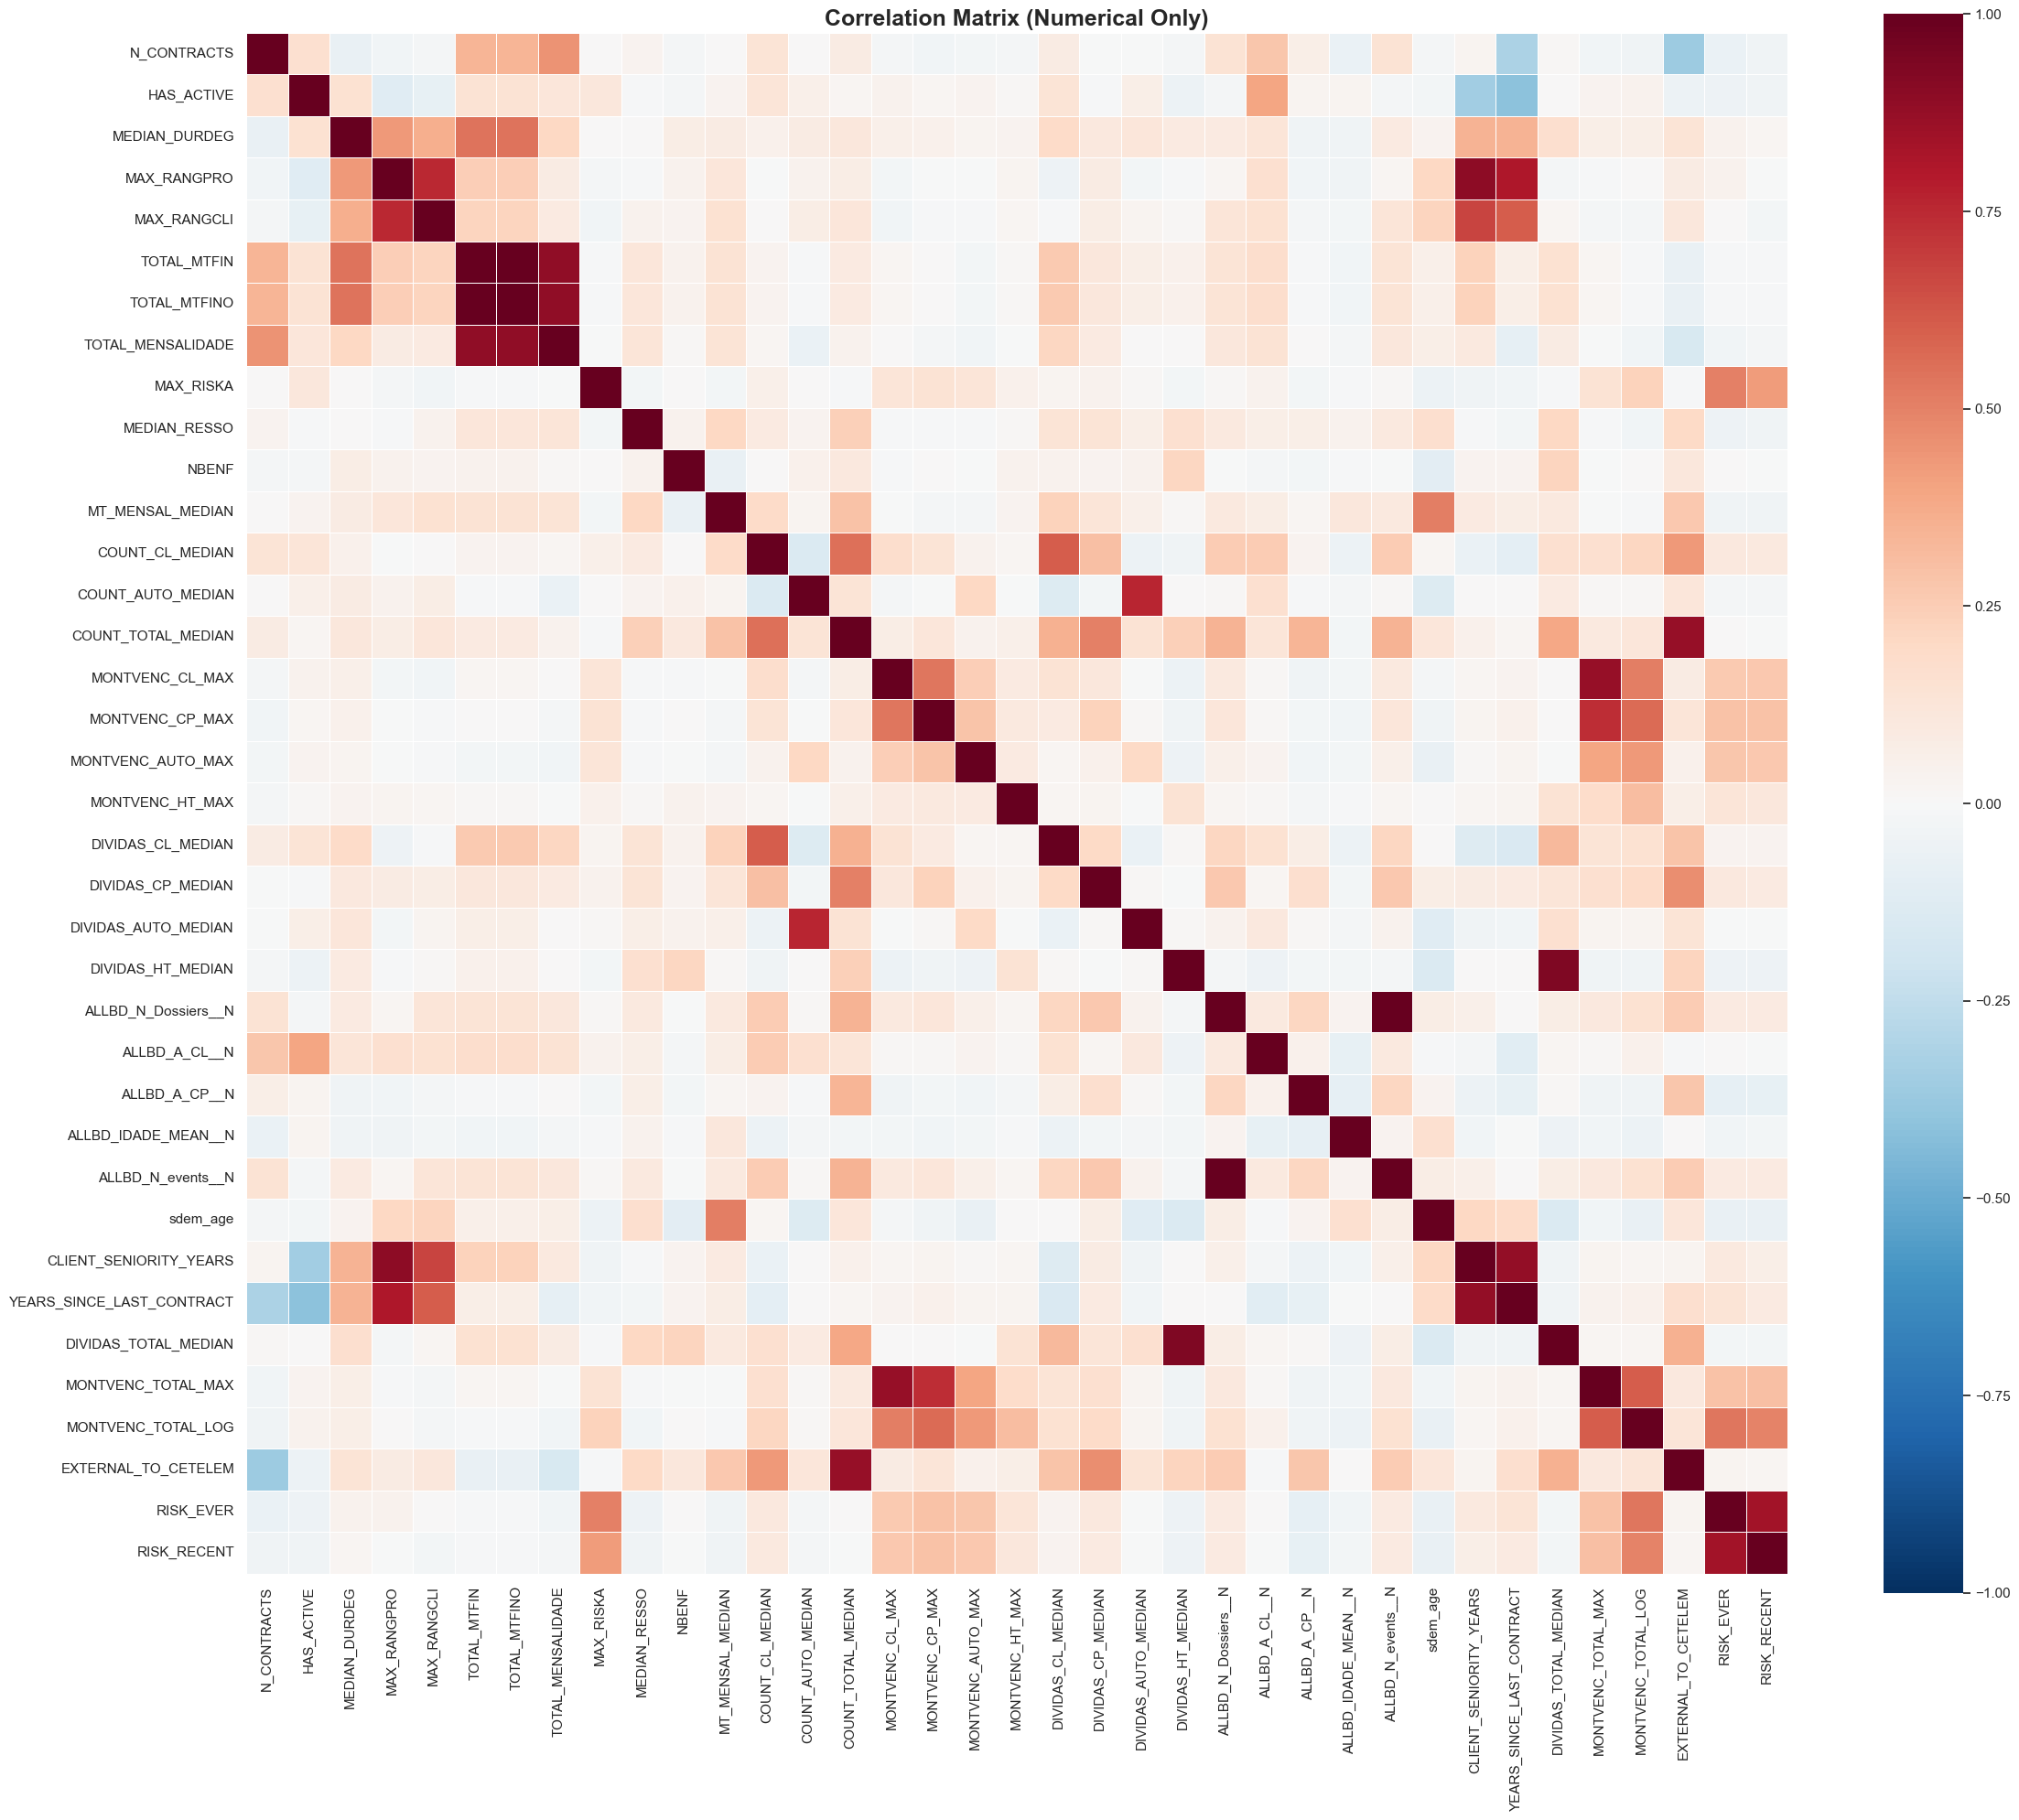

In [45]:
# Correlation matrix (only pure numerical, excluding one-hot)
corr = customer[num_cols].corr()

plt.figure(figsize=(24, 20))
sns.heatmap(
    corr,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix (Numerical Only)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


In [46]:
cols_corr_drop = ['TOTAL_MTFIN','ALLBD_N_events__N', 'DIVIDAS_CL_MEDIAN', 'DIVIDAS_CP_MEDIAN', 'DIVIDAS_AUTO_MEDIAN', 
                    'DIVIDAS_HT_MEDIAN', 'MONTVENC_CL_MAX', 'MONTVENC_CP_MAX', 'MONTVENC_AUTO_MAX', 'MONTVENC_HT_MAX','MONTVENC_TOTAL_MAX']  #, 'MONTVENC_CL_MAX',
                  #'MONTHS_SINCE_LAST_CONTRACT']

customer.drop(columns=cols_corr_drop, inplace=True)
print(f"Dropped {len(cols_corr_drop)} columns")
print(f"New shape: {customer.shape}")


Dropped 11 columns
New shape: (134222, 77)


In [47]:
customer.columns

Index(['CONTRIB', 'N_CONTRACTS', 'HAS_ACTIVE', 'MEDIAN_DURDEG', 'MAX_RANGPRO',
       'MAX_RANGCLI', 'TOTAL_MTFINO', 'TOTAL_MENSALIDADE', 'MAX_RISKA',
       'MEDIAN_RESSO', 'NBENF', 'PRODALP', 'MT_MENSAL_MEDIAN',
       'COUNT_CL_MEDIAN', 'COUNT_AUTO_MEDIAN', 'COUNT_TOTAL_MEDIAN',
       'ALLBD_N_Dossiers__N', 'ALLBD_A_CL__N', 'ALLBD_A_CP__N',
       'ALLBD_IDADE_MEAN__N', 'sdem_age', 'CLIENT_SENIORITY_YEARS',
       'YEARS_SINCE_LAST_CONTRACT', 'DIVIDAS_TOTAL_MEDIAN',
       'MONTVENC_TOTAL_LOG', 'EXTERNAL_TO_CETELEM', 'RISK_EVER', 'RISK_RECENT',
       'sdem_SITFAM_D', 'sdem_SITFAM_F', 'sdem_SITFAM_P', 'sdem_SITFAM_S',
       'sdem_SITFAM_U', 'sdem_SITFAM_Unknown', 'sdem_SITFAM_V',
       'sdem_SITFAM_X', 'sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F',
       'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P',
       'sdem_HABITAT_Unknown', 'sdem_HABITAT_X', 'CSP_CleaningStaff',
       'CSP_Doctor', 'CSP_Driver_Security', 'CSP_HealthProfessional',
       'CSP_Indeterminate',

In [48]:
OUT_PATH = "../data/prepared/customer.parquet"
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
io.save(customer, OUT_PATH)

assert os.path.exists(OUT_PATH), "File not found after save!"
customer_check = pd.read_parquet(OUT_PATH)
assert customer_check.shape == customer.shape, "Reloaded shape mismatch!"
print(f"\n Dataset successfully saved and verified: {OUT_PATH}")
print(f"   Rows: {customer_check.shape[0]:,}  |  Columns: {customer_check.shape[1]}")

[SAVE] ../data/prepared/customer.parquet | shape: (134222, 77)

 Dataset successfully saved and verified: ../data/prepared/customer.parquet
   Rows: 134,222  |  Columns: 77
